In [5]:
import os
from datasets import load_from_disk
import matplotlib.pyplot as plt
import numpy as np
import json
import shutil

In [6]:
DATASET_PATH = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/processed"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Processed dataset not found! Check path.")

print("Loading existing dataset from Drive...")
dataset = load_from_disk(DATASET_PATH)
print("Dataset loaded successfully!")
print(dataset)

Loading existing dataset from Drive...
Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 6308
    })
    val: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 701
    })
    test: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 3004
    })
})


In [7]:
def calculate_area(example):
    img = example["image"]
    return {"resolution": img.width * img.height}

print("Calculating image resolutions...")
for split in dataset.keys():
    dataset[split] = dataset[split].map(calculate_area, desc=f"Calculating {split}", load_from_cache_file=False)

Calculating image resolutions...


Calculating train:   0%|          | 0/6308 [00:00<?, ? examples/s]

Calculating val:   0%|          | 0/701 [00:00<?, ? examples/s]

Calculating test:   0%|          | 0/3004 [00:00<?, ? examples/s]


Processing 'train' split...
=== TRAIN SPLIT STATS ===
25% of images are smaller than: 939,048 pixels (~969x969)
50% of images are smaller than: 1,080,000 pixels (~1039x1039)
75% of images are smaller than: 1,080,000 pixels (~1039x1039)
90% of images are smaller than: 1,080,000 pixels (~1039x1039)
Maximum outlier image:          14,625,792 pixels (~3824x3824)

Saved histogram image to /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/train_resolution_hist.png


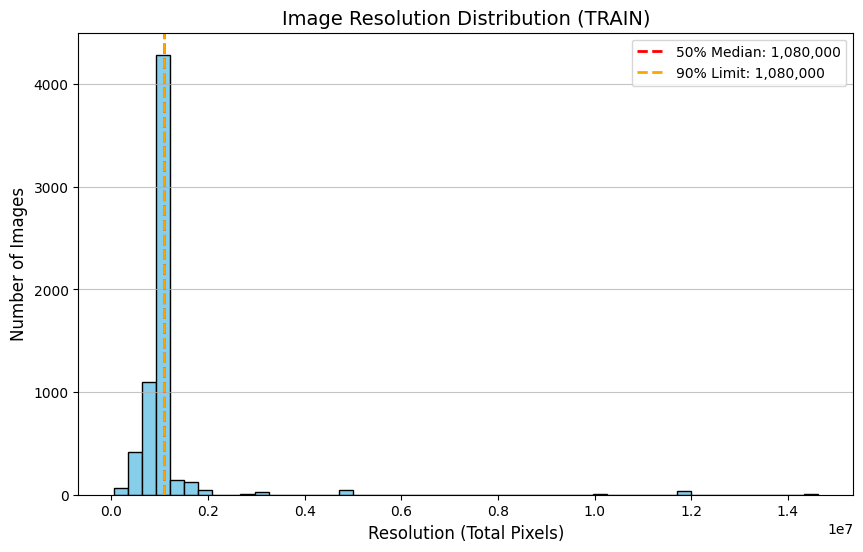


Processing 'val' split...
=== VAL SPLIT STATS ===
25% of images are smaller than: 843,936 pixels (~918x918)
50% of images are smaller than: 1,080,000 pixels (~1039x1039)
75% of images are smaller than: 1,080,000 pixels (~1039x1039)
90% of images are smaller than: 1,080,000 pixels (~1039x1039)
Maximum outlier image:          14,625,792 pixels (~3824x3824)

Saved histogram image to /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/val_resolution_hist.png


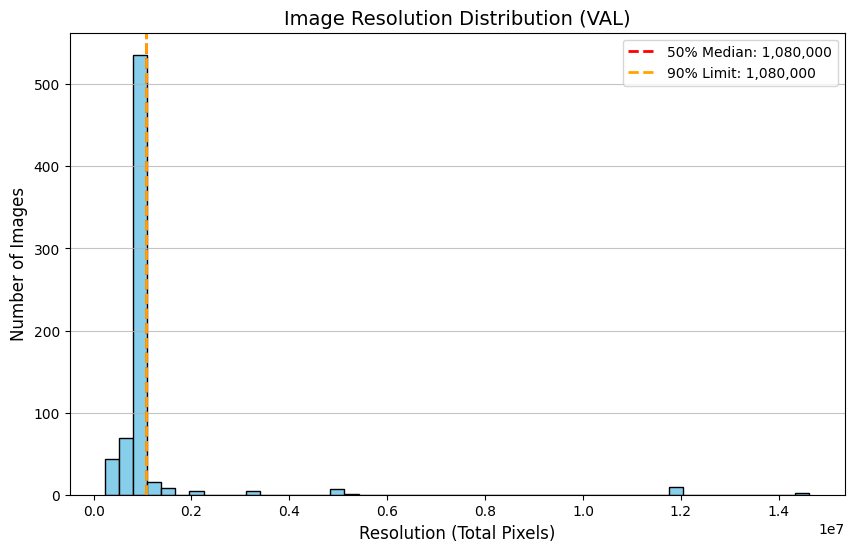


Processing 'test' split...
=== TEST SPLIT STATS ===
25% of images are smaller than: 960,000 pixels (~979x979)
50% of images are smaller than: 1,080,000 pixels (~1039x1039)
75% of images are smaller than: 1,080,000 pixels (~1039x1039)
90% of images are smaller than: 1,080,000 pixels (~1039x1039)
Maximum outlier image:          14,625,792 pixels (~3824x3824)

Saved histogram image to /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/test_resolution_hist.png


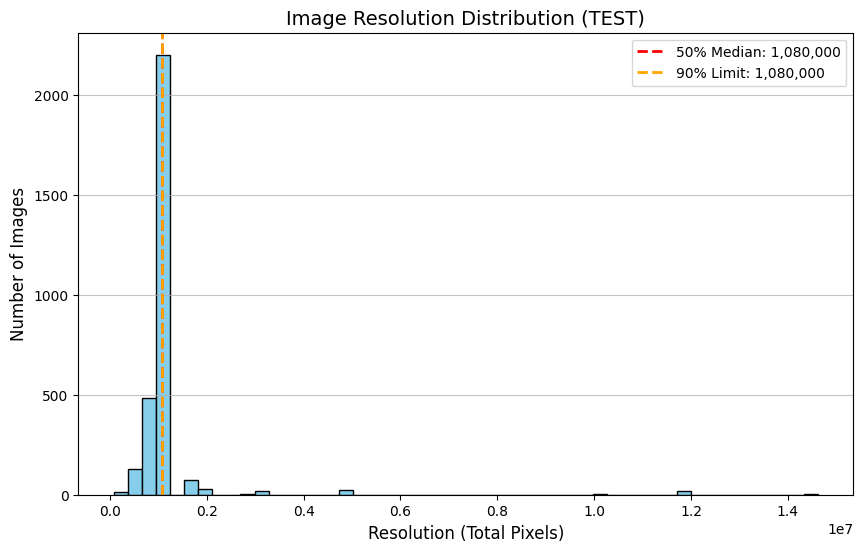


Saved all JSON numerical stats to /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/resolution_stats.json


In [8]:
STATS_DIR = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/stats"
os.makedirs(STATS_DIR, exist_ok=True)

all_stats = {}

for split in dataset.keys():
    print(f"\nProcessing '{split}' split...")
    resolutions = dataset[split]["resolution"]
    min_res = np.min(resolutions)
    max_res = np.max(resolutions)
    mean_res = np.mean(resolutions)

    # Calculate Percentiles
    p25 = np.percentile(resolutions, 25)
    p50 = np.percentile(resolutions, 50) # Same as median
    p75 = np.percentile(resolutions, 75)
    p90 = np.percentile(resolutions, 90)

    # Helper to calculate roughly what dimension (Width x Height) this pixel area is
    def approx_dim(area):
        side = int(np.sqrt(area))
        return f"{side}x{side}"

    split_stats = {
        "count": len(resolutions),
        "min_pixels": int(min_res),
        "max_pixels": int(max_res),
        "mean_pixels": int(mean_res),
        "percentiles": {
            "25%": {"pixels": int(p25), "approx_dim": approx_dim(p25)},
            "50%": {"pixels": int(p50), "approx_dim": approx_dim(p50)},
            "75%": {"pixels": int(p75), "approx_dim": approx_dim(p75)},
            "90%": {"pixels": int(p90), "approx_dim": approx_dim(p90)}
        }
    }
    all_stats[split] = split_stats

    print(f"=== {split.upper()} SPLIT STATS ===")
    print(f"25% of images are smaller than: {p25:,.0f} pixels (~{approx_dim(p25)})")
    print(f"50% of images are smaller than: {p50:,.0f} pixels (~{approx_dim(p50)})")
    print(f"75% of images are smaller than: {p75:,.0f} pixels (~{approx_dim(p75)})")
    print(f"90% of images are smaller than: {p90:,.0f} pixels (~{approx_dim(p90)})")
    print(f"Maximum outlier image:          {max_res:,.0f} pixels (~{approx_dim(max_res)})")
    print("======================================\n")

    plt.figure(figsize=(10, 6))
    plt.hist(resolutions, bins=50, color='skyblue', edgecolor='black')
    plt.axvline(p50, color='red', linestyle='dashed', linewidth=2, label=f'50% Median: {p50:,.0f}')
    plt.axvline(p90, color='orange', linestyle='dashed', linewidth=2, label=f'90% Limit: {p90:,.0f}')

    plt.title(f"Image Resolution Distribution ({split.upper()})", fontsize=14)
    plt.xlabel("Resolution (Total Pixels)", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)

    plot_path = os.path.join(STATS_DIR, f"{split}_resolution_hist.png")
    plt.savefig(plot_path)
    print(f"Saved histogram image to {plot_path}")
    plt.show()

stats_file = os.path.join(STATS_DIR, "resolution_stats.json")
with open(stats_file, "w") as f:
    json.dump(all_stats, f, indent=4)
print(f"\nSaved all JSON numerical stats to {stats_file}")

In [9]:
print("Sorting all dataset splits from smallest to largest...")
for split in dataset.keys():
    dataset[split] = dataset[split].sort("resolution")

print("Sorting complete!")

Sorting all dataset splits from smallest to largest...
Sorting complete!


In [12]:
shutil.rmtree(DATASET_PATH)

In [13]:
TEMP_PATH = DATASET_PATH + "_temp"
print("Saving to temporary path...")
dataset.save_to_disk(TEMP_PATH)

Saving to temporary path...


Saving the dataset (0/3 shards):   0%|          | 0/6308 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/701 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/3004 [00:00<?, ? examples/s]

In [14]:
if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)

shutil.move(TEMP_PATH, DATASET_PATH)

'/content/drive/MyDrive/vlm-finetuning-project1/datasets/processed'